## Объяснение проекта

Представим, что есть платформа, где людям показывают смены: выкладка товара, доставка, уборка, помощь на кухне и так далее. У каждой смены есть место, время, оплата, длительность, работодатель, тип задачи и число нужных исполнителей (`capacity`). У каждого пользователя есть локация, признак строгой локации и медкнижка.

Наша задача в рамкх хакатона: когда приходит новая смена, быстро вернуть список пользователей, которым эту смену стоит предложить. Нам нужно **ранжирование**: посчитать score для кандидатов и отсортировать так, чтобы в TOP-10 чаще попадали люди, которые реально откликнутся или пойдут работать.

Процесс проекта выглядит так: (чисто моё мнение, обсуждаемо)

1. **Понять данные.** Проверяем, что значат `user`, `shift`, `event`, где ключи, даты, пропуски, дубликаты и возможные утечки;
2. **Собрать обучающие пары.** Из событий строим пары `user_id + shift_id`. Позитивный пример: пользователь сделал `APPLY` или `FINISHED`; негативный пример: например, только посмотрел (`VIEW`) и не откликнулся;
3. **Не подсмотреть будущее.** Для признаков нельзя использовать события, которые случились после момента, когда мы должны были сделать предсказание;
4. **Сделать признаки.** Например: совпадает ли локация, есть ли медкнижка, сколько раз пользователь раньше откликался, какие task_type предпочитает, как часто работал у этого работодателя, подходит ли ему длительность/оплата;
5. **Обучить модель.** Baseline использует `LogisticRegression`, но можно заменить на более сильную модель или learning-to-rank подход, сохранив контракт артефактов;
6. **Интегрировать в сервис.** В `prepare` удобно предрассчитать тяжелые таблицы/агрегаты, а в `predict` нужно быстро вернуть top пользователей для конкретной смены;
7. **Проверить метрику.** Eval вызывает `predict`, берет TOP-10, сравнивает с фактическими откликами и считает ROC-AUC с ограничением FPR, зависящим от `capacity`;
8. **Довести до production-like качества.** Тесты, отсутствие падений, приемлемая latency, понятные артефакты модели и воспроизводимое обучение.


## Импорты, пути и загрузка данных

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data" / "train").exists():
    PROJECT_ROOT = Path("..").resolve()

TRAIN_DIR = PROJECT_ROOT / "data" / "train"
USER_PATH = TRAIN_DIR / "train_user.csv"
SHIFT_PATH = TRAIN_DIR / "train_shift.csv"
EVENT_PATH = TRAIN_DIR / "train_event.csv"

In [4]:
users_raw = pd.read_csv(USER_PATH)
shifts_raw = pd.read_csv(SHIFT_PATH)
events_raw = pd.read_csv(EVENT_PATH)

datasets = {
    "users_raw": users_raw,
    "shifts_raw": shifts_raw,
    "events_raw": events_raw,
}

overview = []
for name, df in datasets.items():
    overview.append(
        {
            "dataset": name,
            "rows": len(df),
            "columns": df.shape[1],
            "memory_mb": df.memory_usage(deep=True).sum() / 1024 / 1024,
            "exact_duplicate_rows": int(df.duplicated().sum()),
        }
    )

display(pd.DataFrame(overview))

display(Markdown("**Первые строки users**"))
display(users_raw.head())
display(Markdown("**Первые строки shifts**"))
display(shifts_raw.head())
display(Markdown("**Первые строки events**"))
display(events_raw.head())

,dataset,rows,columns,memory_mb,exact_duplicate_rows
0,users_raw,6161,4,0.534804,0
1,shifts_raw,45956,11,16.744064,0
2,events_raw,588595,5,158.471806,0


**Первые строки users**

,location_id,is_strict_location,id,has_mk
0,32,False,2223888b9607301686f0f19b856aa218,True
1,254,False,401f7d0cf994af0397966abb6e73c2c7,True
2,234,False,02c8966fce79f14cf65f54d300678995,True
3,242,False,5b896a6d98134a1bdc7a80cf74841e01,True
4,38,False,eb3b9ea10eaf6877f83d78cfd947a3b8,True


**Первые строки shifts**

,id,start_at,location_id,task_type,employer_id,workplace_id,need_mk,id_differential,hours,reward,capacity
0,57080,2026-01-01 07:00:00+00:00,234,Выкладка товара,02d2b372ccc7404c03bf705d67360723,67cffef2e08cf63c214fc0b9f6273cd5,True,False,12,2800.0,1
1,59080,2026-01-01 07:00:00+00:00,41,Уборка помещений,6cda58e6bf56ba0ddde0c84212300104,48c8cb23493ca2e467a207d840cdb59e,True,False,12,2500.0,5
2,32676,2026-01-01 07:00:00+00:00,234,Выкладка товара,02d2b372ccc7404c03bf705d67360723,6d8a2900d0cd692005b919959d9f3e2b,True,False,12,3700.0,1
3,37968,2026-01-01 08:00:00+00:00,166,Выкладка товара,fb3d1aaa7ddb54fd11604d5529a7774b,22e8cc4635d2e9ca20095842983559aa,True,False,15,5750.0,1
4,9587,2026-01-01 08:00:00+00:00,234,Выкладка товара,02d2b372ccc7404c03bf705d67360723,7e17fba7df94be7f98948340eee1935c,True,False,12,1300.0,1


**Первые строки events**

,id,shift_id,user_id,interaction,ts
0,3e0c68e79a79f3cfbb5dc33a94539538,64679,d0b587858e4eba68a2d5b71dd7cc91b3,VIEW,2026-02-23
1,4219556E8C93233128D8218577DD9F06,64679,d0b587858e4eba68a2d5b71dd7cc91b3,APPLY,2026-02-23
2,0BF1B8CD6627920077C54DEA87713AA5,64679,d0b587858e4eba68a2d5b71dd7cc91b3,FINISHED,2026-02-23
3,65664e85b7d79b5f370ea5db40b40cef,65231,d0b587858e4eba68a2d5b71dd7cc91b3,VIEW,2026-02-24
4,959BFA3BE2079E32FD063B60F7251419,65231,d0b587858e4eba68a2d5b71dd7cc91b3,APPLY,2026-02-24


## Контракты схем и качество

In [5]:
expected_columns = {
    "users": ["location_id", "is_strict_location", "id", "has_mk"],
    "shifts": [
        "id",
        "start_at",
        "location_id",
        "task_type",
        "employer_id",
        "workplace_id",
        "need_mk",
        "id_differential",
        "hours",
        "reward",
        "capacity",
    ],
    "events": ["id", "shift_id", "user_id", "interaction", "ts"],
}

schema_check = []
for name, df in [("users", users_raw), ("shifts", shifts_raw), ("events", events_raw)]:
    expected = expected_columns[name]
    schema_check.append(
        {
            "dataset": name,
            "columns_ok": list(df.columns) == expected,
            "missing_columns": sorted(set(expected) - set(df.columns)),
            "extra_columns": sorted(set(df.columns) - set(expected)),
        }
    )

display(pd.DataFrame(schema_check))

missing = []
for name, df in [("users", users_raw), ("shifts", shifts_raw), ("events", events_raw)]:
    for col in df.columns:
        missing.append(
            {
                "dataset": name,
                "column": col,
                "missing": int(df[col].isna().sum()),
                "missing_rate": float(df[col].isna().mean()),
                "nunique": int(df[col].nunique(dropna=False)),
                "dtype_raw": str(df[col].dtype),
            }
        )

display(
    pd.DataFrame(missing).sort_values(
        ["dataset", "missing_rate", "column"], ascending=[True, False, True]
    )
)

,dataset,columns_ok,missing_columns,extra_columns
0,users,True,[],[]
1,shifts,True,[],[]
2,events,True,[],[]


,dataset,column,missing,missing_rate,nunique,dtype_raw
15,events,id,0,0.0,296674,str
18,events,interaction,0,0.0,5,str
16,events,shift_id,0,0.0,63280,int64
19,events,ts,0,0.0,81,str
17,events,user_id,0,0.0,6200,str
14,shifts,capacity,0,0.0,10,int64
8,shifts,employer_id,0,0.0,56,str
12,shifts,hours,0,0.0,22,int64
4,shifts,id,0,0.0,45956,int64
11,shifts,id_differential,0,0.0,2,bool


In [6]:
VALID_INTERACTIONS = ["VIEW", "APPLY", "FINISHED", "USER_CANCEL", "SYSTEM_CANCEL"]


def normalize_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.astype("boolean")
    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
    }
    return series.astype(str).str.strip().str.lower().map(mapping).astype("boolean")


users = users_raw.copy()
users["id"] = users["id"].astype(str)
users["location_id"] = users["location_id"].astype(str)
users["is_strict_location"] = normalize_bool(users["is_strict_location"])
users["has_mk"] = normalize_bool(users["has_mk"])

shifts = shifts_raw.copy()
for col in ["id", "location_id", "task_type", "employer_id", "workplace_id"]:
    shifts[col] = shifts[col].astype(str)
for col in ["need_mk", "id_differential"]:
    shifts[col] = normalize_bool(shifts[col])
for col in ["hours", "reward", "capacity"]:
    shifts[col] = pd.to_numeric(shifts[col], errors="coerce")
shifts["start_at"] = pd.to_datetime(shifts["start_at"], utc=True, errors="coerce")
shifts["shift_date"] = shifts["start_at"].dt.date
shifts["start_hour"] = shifts["start_at"].dt.hour
shifts["weekday"] = shifts["start_at"].dt.day_name()
shifts["reward_per_hour"] = shifts["reward"] / shifts["hours"].replace(0, np.nan)

events = events_raw.copy()
for col in ["id", "shift_id", "user_id"]:
    events[col] = events[col].astype(str)
events["interaction"] = events["interaction"].astype(str).str.upper()
events["ts"] = pd.to_datetime(events["ts"], utc=True, errors="coerce")
events["event_date"] = events["ts"].dt.date
events["event_hour"] = events["ts"].dt.hour

print("Invalid interactions:", sorted(set(events["interaction"]) - set(VALID_INTERACTIONS)))
print("Users after normalization:", users.shape)
print("Shifts after normalization:", shifts.shape)
print("Events after normalization:", events.shape)

Invalid interactions: []
Users after normalization: (6161, 4)
Shifts after normalization: (45956, 15)
Events after normalization: (588595, 7)


In [7]:
key_checks = pd.DataFrame(
    [
        {
            "dataset": "users",
            "key": "id",
            "rows": len(users),
            "unique_keys": users["id"].nunique(),
            "duplicate_key_rows": int(users.duplicated("id").sum()),
        },
        {
            "dataset": "shifts",
            "key": "id",
            "rows": len(shifts),
            "unique_keys": shifts["id"].nunique(),
            "duplicate_key_rows": int(shifts.duplicated("id").sum()),
        },
        {
            "dataset": "events",
            "key": "id",
            "rows": len(events),
            "unique_keys": events["id"].nunique(),
            "duplicate_key_rows": int(events.duplicated("id").sum()),
        },
    ]
)
display(key_checks)

# event.id ведет себя как идентификатор пачки/показа списка, а не как уникальный id строки.
event_id_groups = events.groupby("id", as_index=False).agg(
    rows=("id", "size"),
    shifts=("shift_id", "nunique"),
    users=("user_id", "nunique"),
    interactions=("interaction", "nunique"),
)

display(Markdown("**Размеры групп с одинаковым event.id**"))
display(
    event_id_groups["rows"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).to_frame().T
)

display(Markdown("**Самые крупные группы одинакового event.id**"))
display(event_id_groups.sort_values("rows", ascending=False).head(10))

sample_duplicate_id = (
    event_id_groups.query("rows > 1").sort_values("rows", ascending=False).iloc[0]["id"]
)
display(Markdown(f"**Пример строк с одним event.id = `{sample_duplicate_id}`**"))
display(events.query("id == @sample_duplicate_id").head(12))

,dataset,key,rows,unique_keys,duplicate_key_rows
0,users,id,6161,6161,0
1,shifts,id,45956,45956,0
2,events,id,588595,296674,291921


**Размеры групп с одинаковым event.id**

,count,mean,std,min,50%,75%,90%,95%,99%,99.9%,max
rows,296674.0,1.983979,3.633992,1.0,1.0,1.0,4.0,7.0,19.0,42.0,81.0


**Самые крупные группы одинакового event.id**

,id,rows,shifts,users,interactions
151531,82F2A3DCF09695DD7D8BC2A7637EC7E7,81,81,1,1
61826,3570681EA4710E992860DECE7F6CE02C,79,79,1,1
230560,C9763C6A65DB2D65DAB2CC615D8A9935,79,79,1,1
171168,93EE057B68A4034E1187BEDDB0479C24,78,78,1,1
244515,D62793FA07758D47E60AD99A115D4669,78,78,1,1
261551,E5DA24D7A6BEA626174BFF3A2F5A40AA,78,78,1,1
29066,190BA7AEF808C8153BEEFBDFE28BB8F3,74,74,1,1
103873,59D41B30E7382CE9A967B6168149CF56,74,74,1,1
247653,D91DD94830D499C56766AD2ECDFE5EF9,74,74,1,1
160659,8AF80C3F29357AC2967B7FBA9FF3B68B,74,74,1,1


**Пример строк с одним event.id = `82F2A3DCF09695DD7D8BC2A7637EC7E7`**

,id,shift_id,user_id,interaction,ts,event_date,event_hour
34672,82F2A3DCF09695DD7D8BC2A7637EC7E7,89016,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34705,82F2A3DCF09695DD7D8BC2A7637EC7E7,90832,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34706,82F2A3DCF09695DD7D8BC2A7637EC7E7,90840,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34707,82F2A3DCF09695DD7D8BC2A7637EC7E7,90842,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34708,82F2A3DCF09695DD7D8BC2A7637EC7E7,90854,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34709,82F2A3DCF09695DD7D8BC2A7637EC7E7,108404,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34710,82F2A3DCF09695DD7D8BC2A7637EC7E7,90866,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34711,82F2A3DCF09695DD7D8BC2A7637EC7E7,112513,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34713,82F2A3DCF09695DD7D8BC2A7637EC7E7,90923,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0
34714,82F2A3DCF09695DD7D8BC2A7637EC7E7,90934,f29c88114259e5bd27b3b0b9ea40b6dd,VIEW,2026-01-31 00:00:00+00:00,2026-01-31,0


### Вывод по `event.id`

В данных один и тот же `event.id` часто соответствует одному пользователю и множеству разных смен. Поэтому использовать только `event.id` как primary key опасно. Для обучения и сервиса лучше рассмотреть суррогатный row id или составной ключ вроде `event.id + shift_id + user_id + interaction + ts`, иначе VIEW-события массово перезаписываются/удаляются.

## Связи между таблицами и FK

In [8]:
known_shift_ids = set(shifts["id"])
known_user_ids = set(users["id"])

events["shift_known"] = events["shift_id"].isin(known_shift_ids)
events["user_known"] = events["user_id"].isin(known_user_ids)
events["both_known"] = events["shift_known"] & events["user_known"]

fk_summary = pd.DataFrame(
    [
        {
            "check": "event.shift_id exists in train_shift",
            "rows_ok": int(events["shift_known"].sum()),
            "rows_total": len(events),
            "rate_ok": events["shift_known"].mean(),
            "distinct_missing_keys": events.loc[~events["shift_known"], "shift_id"].nunique(),
        },
        {
            "check": "event.user_id exists in train_user",
            "rows_ok": int(events["user_known"].sum()),
            "rows_total": len(events),
            "rate_ok": events["user_known"].mean(),
            "distinct_missing_keys": events.loc[~events["user_known"], "user_id"].nunique(),
        },
        {
            "check": "event has both known shift and known user",
            "rows_ok": int(events["both_known"].sum()),
            "rows_total": len(events),
            "rate_ok": events["both_known"].mean(),
            "distinct_missing_keys": np.nan,
        },
    ]
)
display(fk_summary)

display(Markdown("**События по interaction и наличию ключей в train-справочниках**"))
display(pd.crosstab(events["interaction"], [events["shift_known"], events["user_known"]]))

,check,rows_ok,rows_total,rate_ok,distinct_missing_keys
0,event.shift_id exists in train_shift,389902,588595,0.662428,18960.0
1,event.user_id exists in train_user,418038,588595,0.710230,1865.0
2,event has both known shift and known user,277014,588595,0.470636,NaN


**События по interaction и наличию ключей в train-справочниках**

shift_known    False           True         
user_known     False   True    False   True 
interaction                                 
APPLY           2237    5388    5316   12877
FINISHED         927    2402    2251    5559
SYSTEM_CANCEL    561    1274    1331    3207
USER_CANCEL      748    1708    1734    4107
VIEW           53196  130252  102256  251264

### Что это для нас значит?

Для обучения модели на признаках смены и пользователя мы можем использовать только события, которые удалось связать и с `train_shift`, и с `train_user`. Остальные строки не бесполезны: они могут относиться к будущим/валидационным сменам или пользователям вне текущего справочника. Но мы не можем их бездумно джойнить в train-frame

## Временная структура и риск утечек

,entity,min,max,n_days,n_unique_timestamps
0,shifts.start_at,2026-01-01 07:00:00+00:00,2026-02-26 20:00:00+00:00,57,1943
1,events.ts,2026-01-01 00:00:00+00:00,2026-03-22 00:00:00+00:00,81,81


**Часы в event.ts**

,event_rows
event_hour,
0,588595


**События после start_at при текущем формате ts**

after_shift_start,False,True
interaction,,
APPLY,12877,0
FINISHED,5545,14
SYSTEM_CANCEL,3207,0
USER_CANCEL,4094,13
VIEW,251264,0


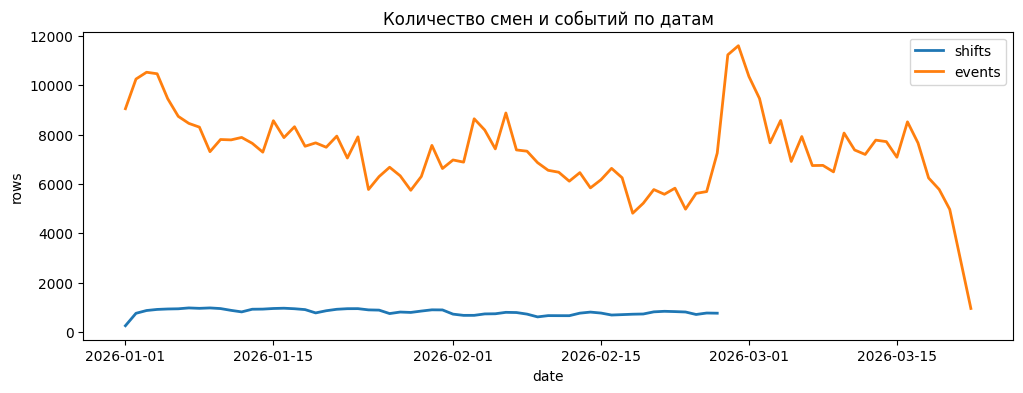

In [9]:
time_summary = pd.DataFrame(
    [
        {
            "entity": "shifts.start_at",
            "min": shifts["start_at"].min(),
            "max": shifts["start_at"].max(),
            "n_days": shifts["shift_date"].nunique(),
            "n_unique_timestamps": shifts["start_at"].nunique(),
        },
        {
            "entity": "events.ts",
            "min": events["ts"].min(),
            "max": events["ts"].max(),
            "n_days": events["event_date"].nunique(),
            "n_unique_timestamps": events["ts"].nunique(),
        },
    ]
)
display(time_summary)

hour_check = events["event_hour"].value_counts().sort_index().rename("event_rows").to_frame()
display(Markdown("**Часы в event.ts**"))
display(hour_check)

valid_events = events.loc[events["both_known"]].merge(
    shifts[["id", "start_at", "shift_date", "task_type", "capacity"]].rename(
        columns={"id": "shift_id"}
    ),
    on="shift_id",
    how="inner",
)
valid_events["after_shift_start"] = valid_events["ts"] > valid_events["start_at"]

display(Markdown("**События после start_at при текущем формате ts**"))
display(pd.crosstab(valid_events["interaction"], valid_events["after_shift_start"]))

fig, ax = plt.subplots(figsize=(12, 4))
shifts.groupby("shift_date").size().plot(ax=ax, label="shifts", linewidth=2)
events.groupby("event_date").size().plot(ax=ax, label="events", linewidth=2)
ax.set_title("Количество смен и событий по датам")
ax.set_xlabel("date")
ax.set_ylabel("rows")
ax.legend()
plt.show()

### Вывод по времени

`event.ts` хранит только дату, поэтому все события имеют время `00:00:00`. Если смена началась в 07:00, то `FINISHED` в тот же календарный день формально выглядит как событие до начала смены. Для нормального feature engineering лучше строить признаки из истории строго до даты/момента прогнозирования и не использовать outcome текущей смены как фичу

## Пользователи

,metric,value
0,users,6161.000000
1,unique user locations,3417.000000
2,has_mk rate,0.776173
3,is_strict_location rate,0.534004


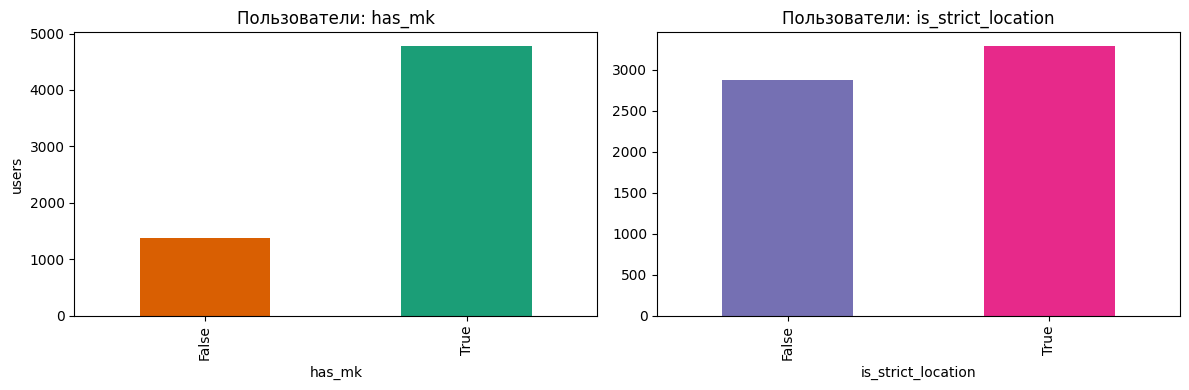

**Top-15 пользовательских локаций**

,location_id,users
0,234,554
1,158,394
2,121,186
3,308,82
4,13,81
5,41,74
6,61,56
7,64,53
8,249,44
9,21,33


In [10]:
user_summary = pd.DataFrame(
    [
        {"metric": "users", "value": len(users)},
        {"metric": "unique user locations", "value": users["location_id"].nunique()},
        {"metric": "has_mk rate", "value": users["has_mk"].mean()},
        {"metric": "is_strict_location rate", "value": users["is_strict_location"].mean()},
    ]
)
display(user_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
users["has_mk"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#d95f02", "#1b9e77"]
)
axes[0].set_title("Пользователи: has_mk")
axes[0].set_xlabel("has_mk")
axes[0].set_ylabel("users")
users["is_strict_location"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#7570b3", "#e7298a"]
)
axes[1].set_title("Пользователи: is_strict_location")
axes[1].set_xlabel("is_strict_location")
plt.tight_layout()
plt.show()

display(Markdown("**Top-15 пользовательских локаций**"))
display(
    users["location_id"]
    .value_counts()
    .head(15)
    .rename_axis("location_id")
    .reset_index(name="users")
)

## Смены

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
capacity,45956.0,1.163744,0.689774,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,4.0,10.0
hours,45956.0,9.704217,2.774044,1.000000,4.000000,5.000000,7.000000,11.000000,12.000000,13.000000,14.0,23.0
reward,45956.0,2863.700061,1471.835610,1000.000000,1050.000000,1150.000000,1800.000000,2600.000000,3700.000000,5500.000000,8750.0,15500.0
reward_per_hour,45956.0,298.916080,145.705615,66.666667,91.666667,131.129808,233.333333,292.307692,342.857143,483.333333,797.5,9500.0


,feature,true_count,true_rate
0,need_mk,41589,0.904974
1,id_differential,3510,0.076377


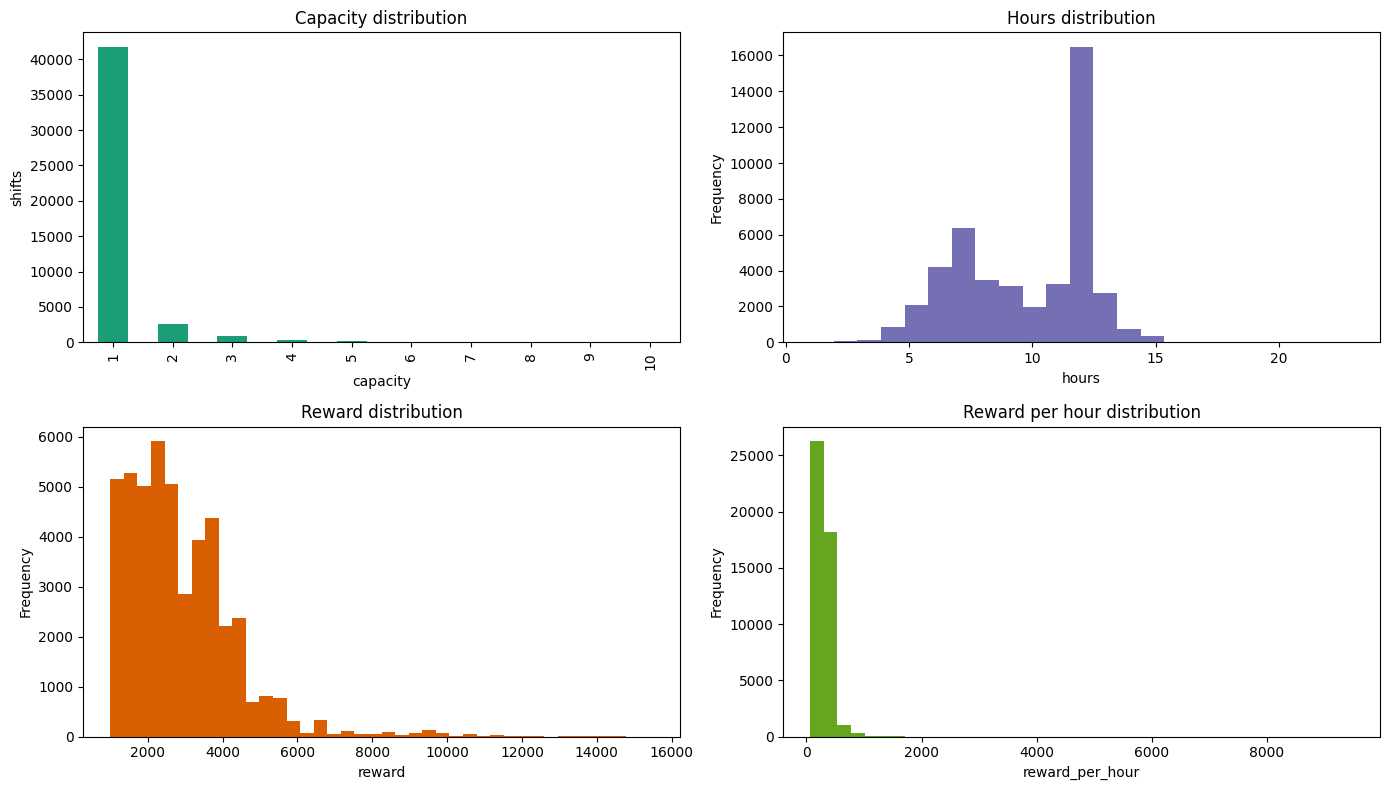

In [11]:
shift_numeric = (
    shifts[["capacity", "hours", "reward", "reward_per_hour"]]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)
display(shift_numeric)

binary_shift = pd.DataFrame(
    [
        {
            "feature": "need_mk",
            "true_count": int(shifts["need_mk"].sum()),
            "true_rate": shifts["need_mk"].mean(),
        },
        {
            "feature": "id_differential",
            "true_count": int(shifts["id_differential"].sum()),
            "true_rate": shifts["id_differential"].mean(),
        },
    ]
)
display(binary_shift)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
shifts["capacity"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="#1b9e77")
axes[0, 0].set_title("Capacity distribution")
axes[0, 0].set_xlabel("capacity")
axes[0, 0].set_ylabel("shifts")
shifts["hours"].plot(kind="hist", bins=23, ax=axes[0, 1], color="#7570b3")
axes[0, 1].set_title("Hours distribution")
axes[0, 1].set_xlabel("hours")
shifts["reward"].plot(kind="hist", bins=40, ax=axes[1, 0], color="#d95f02")
axes[1, 0].set_title("Reward distribution")
axes[1, 0].set_xlabel("reward")
shifts["reward_per_hour"].plot(kind="hist", bins=40, ax=axes[1, 1], color="#66a61e")
axes[1, 1].set_title("Reward per hour distribution")
axes[1, 1].set_xlabel("reward_per_hour")
plt.tight_layout()
plt.show()

,task_type,shifts
0,Выкладка товара,21620
1,Обслуживание покупателей,3595
2,Помощь в торговом зале,3487
3,Доставка заказов на авто,2623
4,Мойка посуды и инвентаря,2538
5,Погрузка и разгрузка товара,2410
6,Приготовление пищи,1791
7,Помощь в прикассовой зоне,1744
8,Уборка помещений,1673
9,Сборка заказов,1458


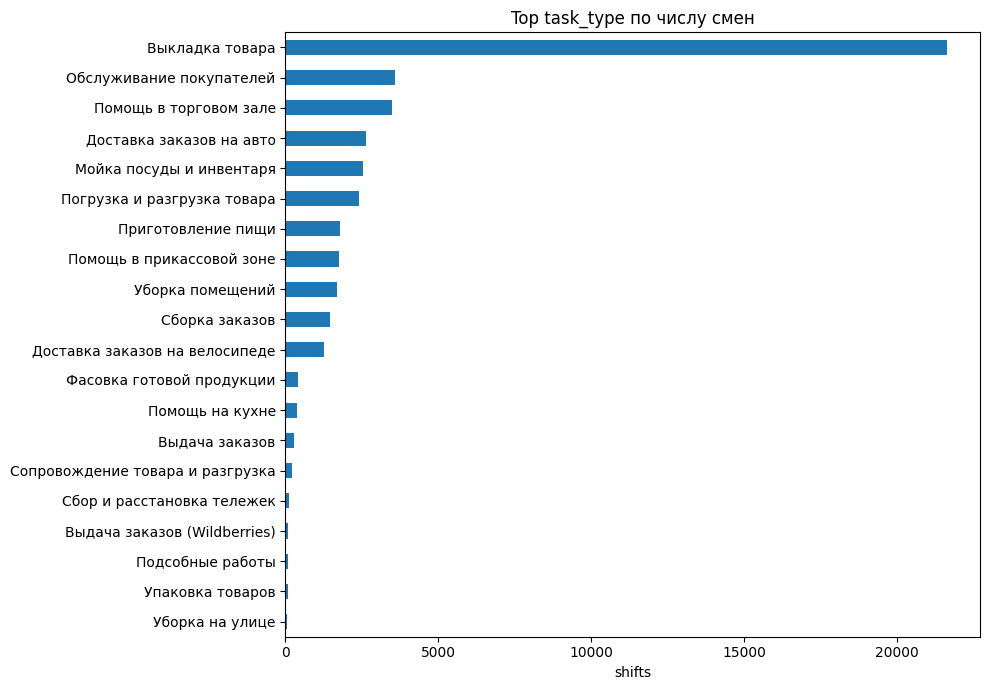

**Top работодателей и рабочих точек**

,employer_id,workplace_id
fb3d1aaa7ddb54fd11604d5529a7774b,15925.0,NaN
02d2b372ccc7404c03bf705d67360723,12164.0,NaN
faff2687685943a75600a311b3ef706c,2442.0,NaN
d10547569bf9ec2f4879eb99060fe4b5,2424.0,NaN
74a4c69e20db838af93ec0eaad6bba6d,1846.0,NaN
1eb3160437623dc77c8ada7752463cc2,1500.0,NaN
fde7f87281be0976480c847c59a65377,1356.0,NaN
13beef986829b8417aa4657feb86f2b6,967.0,NaN
e0480c3c5525389f776aa4fa58a7f72b,681.0,NaN
c1714b6178cdbe470384bdd7ea181f3c,645.0,NaN


In [12]:
top_tasks = (
    shifts["task_type"].value_counts().head(20).rename_axis("task_type").reset_index(name="shifts")
)
display(top_tasks)

fig, ax = plt.subplots(figsize=(10, 7))
top_tasks.sort_values("shifts").plot(
    kind="barh", x="task_type", y="shifts", ax=ax, legend=False, color="#1f78b4"
)
ax.set_title("Top task_type по числу смен")
ax.set_xlabel("shifts")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(Markdown("**Top работодателей и рабочих точек**"))
display(
    pd.concat(
        {
            "employer_id": shifts["employer_id"].value_counts().head(10),
            "workplace_id": shifts["workplace_id"].value_counts().head(10),
        },
        axis=1,
    )
)

## События и воронка interaction

,rows,rate
interaction,,
VIEW,536968,0.912288
APPLY,25818,0.043864
FINISHED,11139,0.018925
USER_CANCEL,8297,0.014096
SYSTEM_CANCEL,6373,0.010827


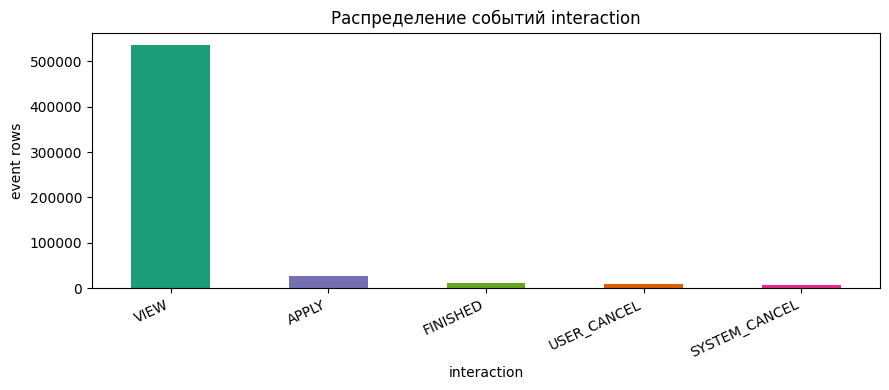

In [13]:
interaction_counts = (
    events["interaction"].value_counts().reindex(VALID_INTERACTIONS).fillna(0).astype(int)
)
interaction_summary = interaction_counts.rename("rows").to_frame()
interaction_summary["rate"] = interaction_summary["rows"] / len(events)
display(interaction_summary)

fig, ax = plt.subplots(figsize=(9, 4))
interaction_counts.plot(
    kind="bar", ax=ax, color=["#1b9e77", "#7570b3", "#66a61e", "#d95f02", "#e7298a"]
)
ax.set_title("Распределение событий interaction")
ax.set_xlabel("interaction")
ax.set_ylabel("event rows")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Формирование train-frame: raw события против baseline дедупликации

In [ ]:
def build_pair_frame(source_events: pd.DataFrame, label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Строим пары user-shift из событий, которые можно связать с train users/shifts."""
    ev = source_events.copy()
    ev = ev[ev["interaction"].isin(VALID_INTERACTIONS)].copy()
    ev = ev.merge(
        shifts[
            [
                "id",
                "start_at",
                "shift_date",
                "location_id",
                "task_type",
                "employer_id",
                "workplace_id",
                "need_mk",
                "hours",
                "reward",
                "capacity",
                "reward_per_hour",
            ]
        ].rename(columns={"id": "shift_id", "location_id": "shift_location_id"}),
        on="shift_id",
        how="inner",
    )
    ev = ev.merge(
        users[["id", "location_id", "has_mk", "is_strict_location"]].rename(
            columns={"id": "user_id", "location_id": "user_location_id"}
        ),
        on="user_id",
        how="inner",
    )
    ev["after_shift_start"] = ev["ts"] > ev["start_at"]
    ev = ev[ev["ts"] <= ev["start_at"]].copy()

    counts = pd.crosstab([ev["user_id"], ev["shift_id"]], ev["interaction"])
    counts = counts.reindex(columns=VALID_INTERACTIONS, fill_value=0).reset_index()
    counts = counts.rename(
        columns={
            "VIEW": "view_cnt",
            "APPLY": "apply_cnt",
            "FINISHED": "finished_cnt",
            "USER_CANCEL": "user_cancel_cnt",
            "SYSTEM_CANCEL": "system_cancel_cnt",
        }
    )
    first_last = ev.groupby(["user_id", "shift_id"], as_index=False).agg(
        first_ts=("ts", "min"),
        last_ts=("ts", "max"),
        n_events=("interaction", "size"),
    )
    pair = first_last.merge(counts, on=["user_id", "shift_id"], how="left")
    pair["target"] = ((pair["apply_cnt"] + pair["finished_cnt"]) > 0).astype(int)

    pair = pair.merge(
        shifts[
            [
                "id",
                "start_at",
                "shift_date",
                "location_id",
                "task_type",
                "employer_id",
                "workplace_id",
                "need_mk",
                "hours",
                "reward",
                "capacity",
                "reward_per_hour",
            ]
        ].rename(columns={"id": "shift_id", "location_id": "shift_location_id"}),
        on="shift_id",
        how="left",
    )
    pair = pair.merge(
        users[["id", "location_id", "has_mk", "is_strict_location"]].rename(
            columns={"id": "user_id", "location_id": "user_location_id"}
        ),
        on="user_id",
        how="left",
    )
    pair["location_match"] = pair["shift_location_id"] == pair["user_location_id"]
    pair["mk_eligible"] = (~pair["need_mk"].astype(bool)) | pair["has_mk"].astype(bool)
    pair["source"] = label
    return pair, ev


# Версия данных как источник: без удаления событий с одинаковым event.id
raw_pairs, raw_joined_events = build_pair_frame(events, "raw_no_event_id_dedup")

# Версия, близкая к текущему
# hackaton/train/training.py: drop_duplicates(subset=["id"], keep="first")
events_first_dedup = events.drop_duplicates(subset=["id"], keep="first").copy()
baseline_pairs, baseline_joined_events = build_pair_frame(
    events_first_dedup, "baseline_event_id_keep_first"
)

# Версия, похожая на поведение сервиса INSERT OR REPLACE
# при последовательной загрузке: останется последняя строка на event.id
events_last_dedup = events.drop_duplicates(subset=["id"], keep="last").copy()
service_like_pairs, service_like_joined_events = build_pair_frame(
    events_last_dedup, "service_like_event_id_keep_last"
)

pair_versions = []
for label, pair, joined in [
    ("raw_no_event_id_dedup", raw_pairs, raw_joined_events),
    ("baseline_event_id_keep_first", baseline_pairs, baseline_joined_events),
    ("service_like_event_id_keep_last", service_like_pairs, service_like_joined_events),
]:
    pair_versions.append(
        {
            "version": label,
            "event_rows_after_join_and_time_filter": len(joined),
            "pairs": len(pair),
            "positive_pairs": int(pair["target"].sum()),
            "positive_rate": pair["target"].mean(),
            "unique_users": pair["user_id"].nunique(),
            "unique_shifts": pair["shift_id"].nunique(),
        }
    )

display(pd.DataFrame(pair_versions))

,version,event_rows_after_join_and_time_filter,pairs,positive_pairs,positive_rate,unique_users,unique_shifts
0,raw_no_event_id_dedup,276987,251264,12877,0.051249,3977,42103
1,baseline_event_id_keep_first,145608,120547,12876,0.106813,3976,30566
2,service_like_event_id_keep_last,145516,120456,12877,0.106902,3975,30344


### Как читать сформированную таблицу выше

`raw_no_event_id_dedup` ближе к исходной информации в CSV. `baseline_event_id_keep_first` показывает, что сейчас фактически использует train-код после `drop_duplicates(subset=["id"])`. `service_like_event_id_keep_last` показывает похожий эффект загрузки в SQLite через `INSERT OR REPLACE`.

Если positive rate почти удваивается после дедупликации, модель учится на другом распределении, чем есть в сырых событиях. Это может дать красивую локальную метрику и плохое поведение в реальном ранжировании

**Target по baseline-compatible train-frame**

,target,pairs,rate
0,0,107671,0.893187
1,1,12876,0.106813


**Число событий на пару user-shift**

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_events,120547.0,1.207894,0.605659,1.0,1.0,1.0,3.0,3.0,3.0,3.0


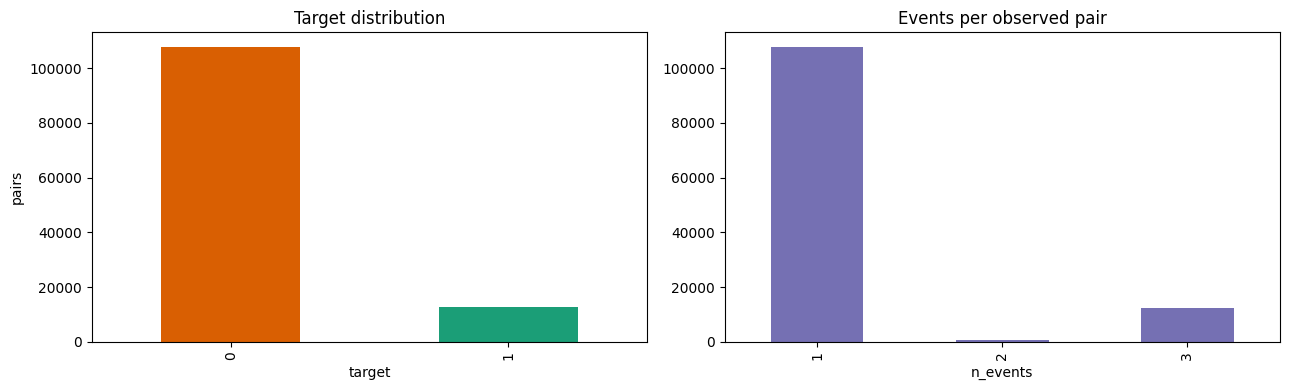

In [ ]:
# Для дальнейшего EDA используем baseline_pairs,
# чтобы напрямую подсветить состояние текущего baseline.
# raw_pairs оставляем рядом как контрольный источник.
pairs = baseline_pairs.copy()

display(Markdown("**Target по baseline-compatible train-frame**"))
display(
    pairs["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="pairs")
    .assign(rate=lambda d: d["pairs"] / len(pairs))
)

display(Markdown("**Число событий на пару user-shift**"))
display(pairs["n_events"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pairs["target"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#d95f02", "#1b9e77"]
)
axes[0].set_title("Target distribution")
axes[0].set_xlabel("target")
axes[0].set_ylabel("pairs")
pairs["n_events"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#7570b3")
axes[1].set_title("Events per observed pair")
axes[1].set_xlabel("n_events")
plt.tight_layout()
plt.show()

## Target в разрезах, важных для модели

In [16]:
def target_rate_table(df: pd.DataFrame, col: str, top_n: int | None = None) -> pd.DataFrame:
    out = (
        df.groupby(col, dropna=False)["target"]
        .agg(pairs="count", positives="sum", positive_rate="mean")
        .reset_index()
    )
    out = out.sort_values("pairs", ascending=False)
    if top_n is not None:
        out = out.head(top_n)
    return out


display(Markdown("**Target by capacity**"))
display(target_rate_table(pairs, "capacity").sort_values("capacity"))

display(Markdown("**Target by task_type, top-15 по числу пар**"))
display(target_rate_table(pairs, "task_type", top_n=15))

display(Markdown("**Target by need_mk, location_match, mk_eligible**"))
for col in ["need_mk", "location_match", "mk_eligible", "has_mk", "is_strict_location"]:
    display(Markdown(f"`{col}`"))
    display(target_rate_table(pairs, col))

**Target by capacity**

,capacity,pairs,positives,positive_rate
0,1,99295,10329,0.104023
1,2,11860,1303,0.109865
2,3,4201,546,0.129969
3,4,1861,276,0.148307
4,5,878,122,0.138952
5,6,685,93,0.135766
6,7,278,42,0.151079
7,8,389,81,0.208226
8,9,84,13,0.154762
9,10,1016,71,0.069882


**Target by task_type, top-15 по числу пар**

,task_type,pairs,positives,positive_rate
3,Выкладка товара,44631,5530,0.123905
12,Обслуживание покупателей,11509,873,0.075854
18,Помощь в торговом зале,11041,1033,0.093560
5,Доставка заказов на авто,9846,886,0.089986
14,Погрузка и разгрузка товара,7212,902,0.125069
10,Мойка посуды и инвентаря,6743,808,0.119828
20,Приготовление пищи,5696,464,0.081461
22,Сборка заказов,4890,525,0.107362
17,Помощь в прикассовой зоне,4527,315,0.069583
25,Уборка помещений,4148,452,0.108968


**Target by need_mk, location_match, mk_eligible**

...

,mk_eligible,pairs,positives,positive_rate
1,True,116472,12876,0.11055
0,False,4075,0,0.00000


`has_mk`

,has_mk,pairs,positives,positive_rate
1,True,111268,11763,0.105718
0,False,9279,1113,0.119948


`is_strict_location`

,is_strict_location,pairs,positives,positive_rate
1,True,80632,7914,0.098150
0,False,39915,4962,0.124314


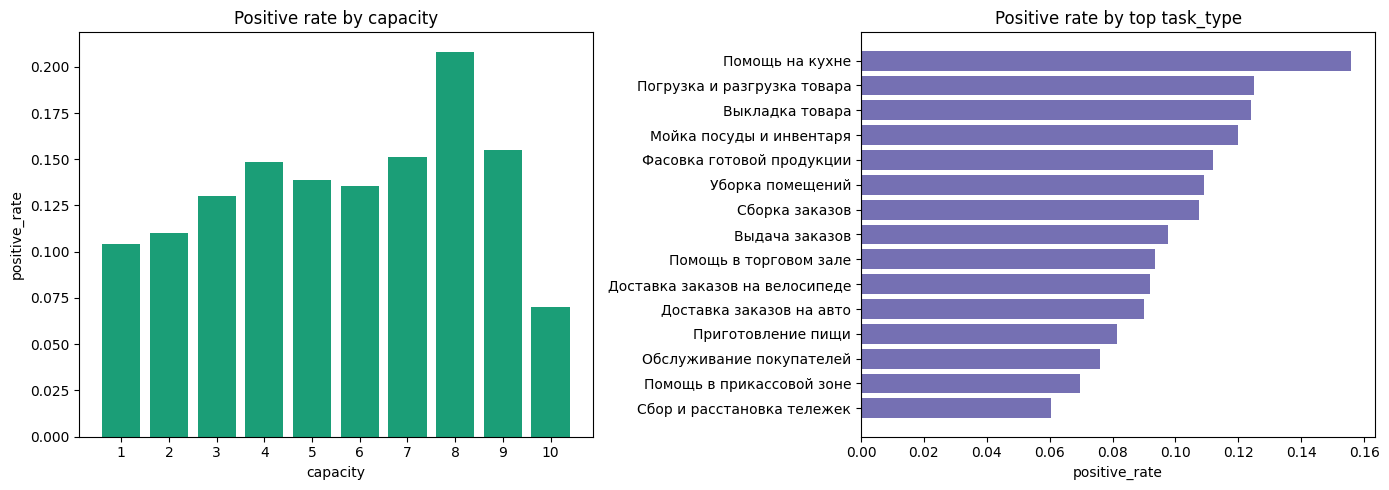

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_rates = target_rate_table(pairs, "capacity").sort_values("capacity")
axes[0].bar(cap_rates["capacity"].astype(str), cap_rates["positive_rate"], color="#1b9e77")
axes[0].set_title("Positive rate by capacity")
axes[0].set_xlabel("capacity")
axes[0].set_ylabel("positive_rate")

task_rates = target_rate_table(pairs, "task_type", top_n=15).sort_values("positive_rate")
axes[1].barh(task_rates["task_type"], task_rates["positive_rate"], color="#7570b3")
axes[1].set_title("Positive rate by top task_type")
axes[1].set_xlabel("positive_rate")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### Модельные подсказки из target-разрезов

- `capacity`, `task_type`, `need_mk`, совпадение локации и история пользователя имеют сильный смысл для ранжирования;
- Для `need_mk=True` пользователь без `has_mk` должен быть жестко отфильтрован или получать score около нуля. В baseline-фиче `need_mk_match = need_mk == has_mk` есть нюанс: если смена не требует медкнижку, пользователь с медкнижкой получает `False`, хотя он подходит. Более естественный признак eligibility: `not need_mk or has_mk`;
- `location_match=True` заметно повышает positive rate, но строгую локацию пользователя (`is_strict_location`) лучше учитывать аккуратно: строгий пользователь может быть менее готов ездить в другие места.

## Смена как объект ранжирования: хватает ли кандидатов и позитивов

In [18]:
shift_level = pairs.groupby("shift_id", as_index=False).agg(
    observed_candidates=("user_id", "nunique"),
    positives=("target", "sum"),
    views=("view_cnt", "sum"),
    applies=("apply_cnt", "sum"),
    finished=("finished_cnt", "sum"),
)
shift_level = (
    shifts[["id", "start_at", "shift_date", "capacity", "task_type", "need_mk", "reward", "hours"]]
    .rename(columns={"id": "shift_id"})
    .merge(
        shift_level,
        on="shift_id",
        how="left",
    )
)
for col in ["observed_candidates", "positives", "views", "applies", "finished"]:
    shift_level[col] = shift_level[col].fillna(0).astype(int)

shift_summary = pd.DataFrame(
    [
        {"metric": "all train shifts", "value": len(shift_level)},
        {
            "metric": "shifts with at least one observed candidate",
            "value": int((shift_level["observed_candidates"] > 0).sum()),
        },
        {
            "metric": "shifts with at least one positive",
            "value": int((shift_level["positives"] > 0).sum()),
        },
        {
            "metric": "observed shifts with fewer than 10 candidates",
            "value": int(
                (
                    (shift_level["observed_candidates"] > 0)
                    & (shift_level["observed_candidates"] < 10)
                ).sum()
            ),
        },
        {
            "metric": "shifts without observed events after baseline filtering",
            "value": int((shift_level["observed_candidates"] == 0).sum()),
        },
    ]
)
display(shift_summary)

display(Markdown("**Кандидаты и позитивы на смену**"))
display(
    shift_level[["observed_candidates", "positives", "views", "applies", "finished"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)

display(Markdown("**Capacity vs observed candidates / positives**"))
display(
    shift_level.groupby("capacity")[["observed_candidates", "positives"]].agg(
        ["count", "mean", "median", "sum"]
    )
)

,metric,value
0,all train shifts,45956
1,shifts with at least one observed candidate,30566
2,shifts with at least one positive,10947
3,observed shifts with fewer than 10 candidates,28123
4,shifts without observed events after baseline ...,15390


**Кандидаты и позитивы на смену**

,count,mean,std,min,50%,75%,90%,95%,99%,max
observed_candidates,45956.0,2.623096,3.769263,0.0,1.0,4.0,7.0,10.0,17.0,64.0
positives,45956.0,0.280181,0.551205,0.0,0.0,0.0,1.0,1.0,2.0,7.0
views,45956.0,2.608734,3.765443,0.0,1.0,4.0,7.0,10.0,17.0,64.0
applies,45956.0,0.280159,0.551157,0.0,0.0,0.0,1.0,1.0,2.0,7.0
finished,45956.0,0.120659,0.337996,0.0,0.0,0.0,1.0,1.0,1.0,4.0


**Capacity vs observed candidates / positives**

observed_candidates                          positives            \
                       count       mean median    sum     count      mean   
capacity                                                                    
1                      41715   2.380319    1.0  99295     41715  0.247609   
2                       2660   4.458647    3.0  11860      2660  0.489850   
3                        946   4.440803    3.0   4201       946  0.577167   
4                        279   6.670251    5.0   1861       279  0.989247   
5                        127   6.913386    5.0    878       127  0.960630   
6                         53  12.924528   10.0    685        53  1.754717   
7                         25  11.120000   12.0    278        25  1.680000   
8                         68   5.720588    5.0    389        68  1.191176   
9                         10   8.400000    6.0     84        10  1.300000   
10                        73  13.917808   12.0   1016        73  0.972603   

                        
         median    sum  
capacity                
1           0.0  10329  
2           0.0   1303  
3           0.0    546  
4           1.0    276  
5           0.0    122  
6           2.0     93  
7           1.0     42  
8           1.0     81  
9           1.5     13  
10          1.0     71

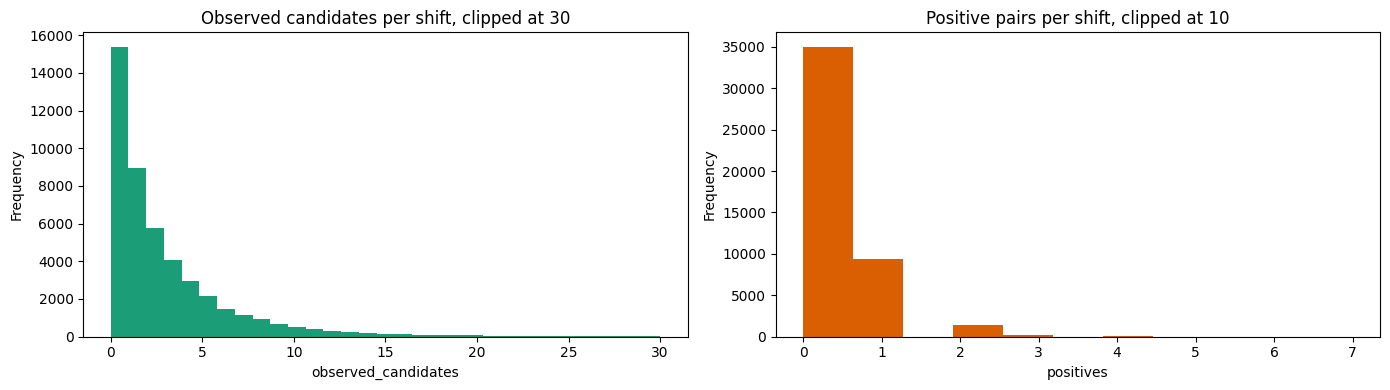

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
shift_level["observed_candidates"].clip(upper=30).plot(
    kind="hist", bins=31, ax=axes[0], color="#1b9e77"
)
axes[0].set_title("Observed candidates per shift, clipped at 30")
axes[0].set_xlabel("observed_candidates")
shift_level["positives"].clip(upper=10).plot(kind="hist", bins=11, ax=axes[1], color="#d95f02")
axes[1].set_title("Positive pairs per shift, clipped at 10")
axes[1].set_xlabel("positives")
plt.tight_layout()
plt.show()

### Что важно для `predict`

Eval всегда просит кандидатов для конкретной смены и смотрит TOP-10. Исторических observed-кандидатов по многим сменам меньше 10, но в `predict` нужно ранжировать всех потенциально подходящих пользователей. Поэтому хорошее решение обычно делает так:

- сначала применяет hard-фильтры: медкнижка, возможно локация/доступность;
- затем строит признаки для пары `user + shift`;
- затем скорит кандидатов и возвращает top-N;
- тяжелые агрегаты считает заранее в `prepare`, чтобы `predict` был быстрым.


## Пользовательская активность

In [20]:
user_level = pairs.groupby("user_id", as_index=False).agg(
    seen_shifts=("shift_id", "nunique"),
    positives=("target", "sum"),
    views=("view_cnt", "sum"),
    applies=("apply_cnt", "sum"),
    finished=("finished_cnt", "sum"),
    user_cancels=("user_cancel_cnt", "sum"),
    system_cancels=("system_cancel_cnt", "sum"),
)
user_level = users.rename(columns={"id": "user_id"}).merge(user_level, on="user_id", how="left")
for col in [
    "seen_shifts",
    "positives",
    "views",
    "applies",
    "finished",
    "user_cancels",
    "system_cancels",
]:
    user_level[col] = user_level[col].fillna(0).astype(int)
user_level["apply_rate_observed"] = user_level["applies"] / user_level["views"].replace(0, np.nan)
user_level["finish_rate_after_apply"] = user_level["finished"] / user_level["applies"].replace(
    0, np.nan
)

display(
    pd.DataFrame(
        [
            {"metric": "all users", "value": len(user_level)},
            {
                "metric": "users with observed train pairs",
                "value": int((user_level["seen_shifts"] > 0).sum()),
            },
            {
                "metric": "users with positive pairs",
                "value": int((user_level["positives"] > 0).sum()),
            },
            {
                "metric": "inactive users in baseline frame",
                "value": int((user_level["seen_shifts"] == 0).sum()),
            },
        ]
    )
)

display(
    user_level[
        [
            "seen_shifts",
            "positives",
            "views",
            "applies",
            "finished",
            "user_cancels",
            "system_cancels",
        ]
    ]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)

display(Markdown("**Самые активные пользователи по observed shifts**"))
display(
    user_level.sort_values("seen_shifts", ascending=False).head(10)[
        [
            "user_id",
            "location_id",
            "has_mk",
            "is_strict_location",
            "seen_shifts",
            "positives",
            "views",
            "applies",
            "finished",
        ]
    ]
)

,metric,value
0,all users,6161
1,users with observed train pairs,3976
2,users with positive pairs,3341
3,inactive users in baseline frame,2185


,count,mean,std,min,50%,75%,90%,95%,99%,max
seen_shifts,6161.0,19.566142,43.457811,0.0,5.0,21.0,50.0,85.0,219.4,723.0
positives,6161.0,2.089920,3.656434,0.0,1.0,2.0,7.0,10.0,17.0,32.0
views,6161.0,19.459016,43.346602,0.0,5.0,20.0,49.0,85.0,219.4,722.0
applies,6161.0,2.089758,3.655750,0.0,1.0,2.0,7.0,10.0,17.0,32.0
finished,6161.0,0.900016,2.396643,0.0,0.0,1.0,3.0,6.0,12.0,29.0
user_cancels,6161.0,0.664503,1.287019,0.0,0.0,1.0,2.0,3.0,6.0,12.0
system_cancels,6161.0,0.520532,1.108091,0.0,0.0,1.0,2.0,3.0,5.0,12.0


**Самые активные пользователи по observed shifts**

,user_id,location_id,has_mk,is_strict_location,seen_shifts,positives,views,applies,finished
4285,db6531083acfb5bc929921450839c44a,5803,True,True,723,15,722,15,1
5032,9789fc29615727bde5bd6442c6f2c699,4770,True,True,632,10,632,10,8
4490,a6ecc44247b45b8f63b22e6c1e1c4bdd,2810,True,True,631,1,631,1,1
1789,d9dd8b75f97d7e7f7c2f1e29f82b052d,279,True,False,507,10,506,10,2
1866,1102028683e370dcc16fc005ac50291a,234,True,False,465,8,465,8,8
2981,5236534c0eab96a2551855fc5e11ddd9,616,True,True,461,2,459,2,1
2954,464f3425073c13332b11319538bee3a8,2607,True,True,436,9,435,9,0
5889,ed9267e385417645a34a13428c9997af,554,True,True,433,12,433,12,10
2736,3c6fda6a42ff6c41a9c98c657216527b,3447,True,True,432,4,432,4,1
1702,eccb89089c7878c07d08874b885340be,512,True,True,426,9,426,9,5


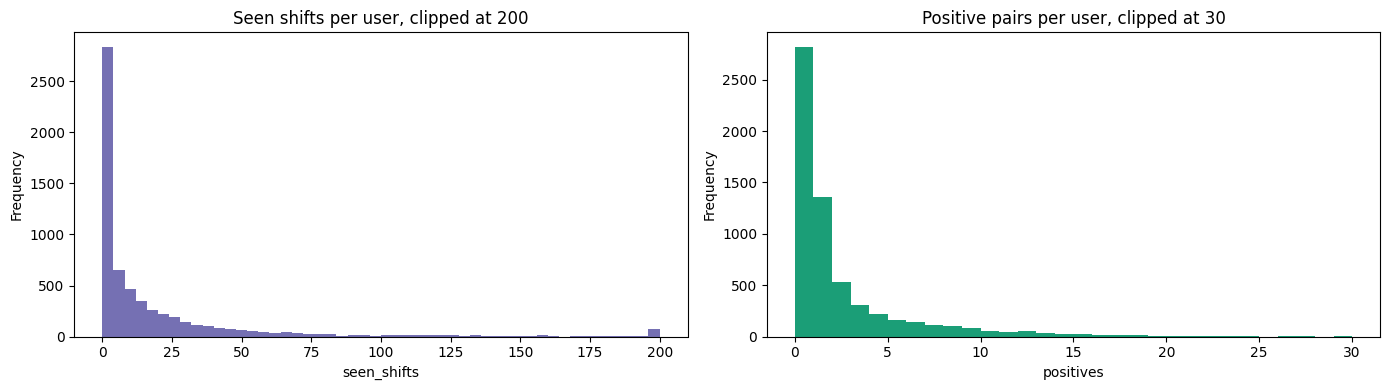

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
user_level["seen_shifts"].clip(upper=200).plot(kind="hist", bins=50, ax=axes[0], color="#7570b3")
axes[0].set_title("Seen shifts per user, clipped at 200")
axes[0].set_xlabel("seen_shifts")
user_level["positives"].clip(upper=30).plot(kind="hist", bins=30, ax=axes[1], color="#1b9e77")
axes[1].set_title("Positive pairs per user, clipped at 30")
axes[1].set_xlabel("positives")
plt.tight_layout()
plt.show()

### Что делать с "неактивными" пользователями

Часть пользователей почти не имеет истории. Для них нужны признаки: локация, медкнижка, строгая локация, глобальные популярности task_type/location/employer, а также аккуратная регуляризация исторических rate-признаков, чтобы один случайный APPLY не превращался в 100% apply-rate

## Временной split, близкий к baseline

**Split border:** `2026-02-15 18:30:00+00:00`

,split,rows,positives,positive_rate,days,unique_shifts,unique_users,min_start_at,max_start_at
0,train,98738,10512,0.106464,46,24907,3702,2026-01-01 07:00:00+00:00,2026-02-15 18:00:00+00:00
1,test,21809,2364,0.108396,12,5659,2581,2026-02-15 18:30:00+00:00,2026-02-26 20:00:00+00:00


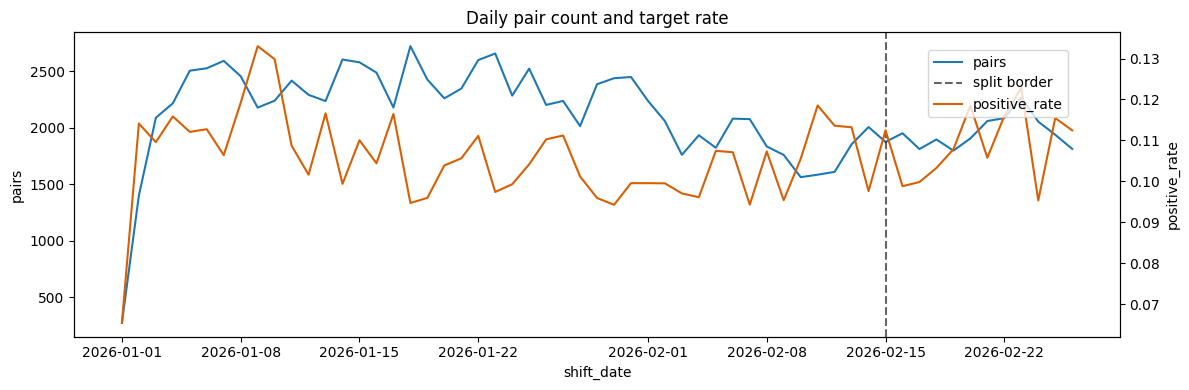

In [22]:
unique_starts = np.array(sorted(pairs["start_at"].dropna().unique()))
split_idx = max(1, int(len(unique_starts) * 0.8))
split_idx = min(split_idx, len(unique_starts) - 1)
split_border = unique_starts[split_idx]

train_pairs = pairs[pairs["start_at"] < split_border].copy()
test_pairs = pairs[pairs["start_at"] >= split_border].copy()

split_summary = []
for name, df in [("train", train_pairs), ("test", test_pairs)]:
    split_summary.append(
        {
            "split": name,
            "rows": len(df),
            "positives": int(df["target"].sum()),
            "positive_rate": df["target"].mean(),
            "days": df["shift_date"].nunique(),
            "unique_shifts": df["shift_id"].nunique(),
            "unique_users": df["user_id"].nunique(),
            "min_start_at": df["start_at"].min(),
            "max_start_at": df["start_at"].max(),
        }
    )

display(Markdown(f"**Split border:** `{split_border}`"))
display(pd.DataFrame(split_summary))

daily = (
    pairs.groupby("shift_date")
    .agg(
        pairs=("target", "size"),
        positives=("target", "sum"),
        positive_rate=("target", "mean"),
        shifts=("shift_id", "nunique"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(daily["shift_date"], daily["pairs"], label="pairs", color="#1f78b4")
ax1.set_ylabel("pairs")
ax2 = ax1.twinx()
ax2.plot(daily["shift_date"], daily["positive_rate"], label="positive_rate", color="#d95f02")
ax2.set_ylabel("positive_rate")
ax1.axvline(
    pd.Timestamp(split_border).date(),
    color="black",
    linestyle="--",
    alpha=0.6,
    label="split border",
)
ax1.set_title("Daily pair count and target rate")
ax1.set_xlabel("shift_date")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

### Почему split по времени обязателен

Если случайно перемешать пары, модель увидит будущее поведение пользователя и смены в train и будет переоценена. Для этой задачи правильнее валидироваться по времени: обучаемся на прошлом, проверяемся на будущих днях. Все исторические признаки тоже должны считаться кумулятивно: только из событий, доступных до прогнозируемой смены/дня

## Проверка текущей baseline-логики и список рисков

In [ ]:
baseline_risks = pd.DataFrame(
    [
        {
            "risk": "event.id is not unique",
            "evidence": f"{events['id'].nunique():,} unique ids for {len(events):,} event rows",
            "impact": (
                "drop_duplicates / INSERT OR REPLACE loses many events "
                "and shifts target distribution"
            ),
            "recommendation": (
                "use row-level surrogate key or composite event key; "
                "do not deduplicate only by event.id"
            ),
        },
        {
            "risk": "event.ts has date-only precision",
            "evidence": (
                f"unique event hours: {sorted(events['event_hour'].dropna().unique().tolist())}"
            ),
            "impact": "same-day outcome events may look pre-shift; leakage filter is weak",
            "recommendation": (
                "build labels separately from features; features only from prior dates/history"
            ),
        },
        {
            "risk": "foreign-key coverage is partial",
            "evidence": f"both known rows: {events['both_known'].sum():,} / {len(events):,}",
            "impact": "many events cannot join to shift/user features in train",
            "recommendation": (
                "track orphan rows; use only joined rows "
                "for supervised frame or enrich dictionaries"
            ),
        },
        {
            "risk": "global user histories leak future",
            "evidence": (
                "baseline computes total user counters and subtracts current pair, "
                "not cumulative-before-shift counters"
            ),
            "impact": "train/test score can be optimistic and features unavailable online",
            "recommendation": "use expanding/time-window aggregations by event date/start_at",
        },
        {
            "risk": "baseline predict uses mostly location + mk filter",
            "evidence": "Repository.find_top_candidates orders by is_strict_location, has_mk, id",
            "impact": (
                "ignores task, reward, employer/workplace affinity, user history and capacity"
            ),
            "recommendation": (
                "score candidate pairs with trained model or "
                "ranking heuristic using precomputed features"
            ),
        },
    ]
)
display(baseline_risks)

,risk,evidence,impact,recommendation
0,event.id is not unique,"296,674 unique ids for 588,595 event rows",drop_duplicates / INSERT OR REPLACE loses many...,use row-level surrogate key or composite event...
1,event.ts has date-only precision,unique event hours: [0],same-day outcome events may look pre-shift; le...,build labels separately from features; feature...
2,foreign-key coverage is partial,"both known rows: 277,014 / 588,595",many events cannot join to shift/user features...,track orphan rows; use only joined rows for su...
3,global user histories leak future,baseline computes total user counters and subt...,train/test score can be optimistic and feature...,use expanding/time-window aggregations by even...
4,baseline predict uses mostly location + mk filter,Repository.find_top_candidates orders by is_st...,"ignores task, reward, employer/workplace affin...",score candidate pairs with trained model or ra...


## Идеи признаков и дальнейших задач

### Hard-фильтры перед моделью

- Если `shift.need_mk=True`, кандидат должен иметь `user.has_mk=True`.
- Если пользователь `is_strict_location=True`, несовпадение локации нужно сильно штрафовать или фильтровать в зависимости от бизнес-правил.
- Не возвращать пользователей, которые физически не подходят под смену, если появятся дополнительные признаки доступности.

### Признаки смены

- `task_type`, `employer_id`, `workplace_id`, `location_id`.
- `hours`, `reward`, `reward_per_hour`, `capacity`.
- `start_hour`, день недели, дата, сезонность и близость к текущему дню.
- Популярность смены/работодателя/точки в прошлом: views, applies, finish rate, cancel rate.

### Признаки пользователя

- Исторические views/applies/finished/cancel counts до момента прогноза.
- Сглаженные apply-rate и finish-rate.
- Предпочитаемые `task_type`, locations, employers, workplaces.
- Активность за последние 7/14/30 дней и давность последнего APPLY/FINISHED.

### Признаки пары user-shift

- Совпадение локации.
- `mk_eligible = not need_mk or has_mk`.
- Работал ли пользователь раньше с этим работодателем/на этой точке/с этим типом задачи.
- Насколько reward/hours похожи на прошлые успешные смены пользователя.
- User-task affinity: доля APPLY/FINISHED пользователя для данного `task_type`.

### Модель и валидация

- Начать можно с logistic regression / CatBoost-like градиентного бустинга / LightGBM, если разрешены зависимости.
- Оптимизировать нужно не только logloss, а качество ранжирования TOP-10 по смене.
- Делать time-based validation, группировать метрики по дню и `capacity`.
- Следить за latency: тяжелые groupby и матрицы кандидат-пара должны быть в `prepare`, а не в `predict`.


## Минимальный план улучшения решения

1. Починить хранение/дедупликацию событий: не терять строки с одинаковым `event.id`.
2. Разделить label и features: `APPLY/FINISHED` текущей смены могут быть target, но не должны становиться доступной фичей для этой же смены.
3. Переписать исторические признаки как cumulative/time-window признаки без будущего.
4. Добавить hard-фильтр по медкнижке и аккуратную обработку строгой локации.
5. Обучить модель на pair-frame и валидировать по последним дням.
6. В `prepare` материализовать user aggregates, shift aggregates и, при необходимости, top-candidate candidate set.
7. В `predict` быстро собрать признаки для кандидатов, получить score, отсортировать и вернуть TOP-N.
8. Проверять не только overall metric, но и срезы: `capacity`, task_type, need_mk, cold users, cold shifts, latency.


## Короткий чек-лист перед моделированием

In [24]:
checklist = pd.DataFrame(
    [
        {
            "item": "No required-column missing values",
            "status": "ok",
            "note": "train CSV has no missing values in required columns",
        },
        {"item": "user.id and shift.id unique", "status": "ok", "note": "safe dictionary keys"},
        {
            "item": "event.id unique",
            "status": "problem",
            "note": "do not use as row-level primary key",
        },
        {
            "item": "foreign keys fully covered",
            "status": "partial",
            "note": "many events reference shifts/users absent from train dictionaries",
        },
        {"item": "timestamps precise enough", "status": "problem", "note": "event.ts is date-only"},
        {
            "item": "target class balance",
            "status": "imbalanced",
            "note": "positive rate around 5-11% depending on event dedup policy",
        },
        {"item": "time split available", "status": "ok", "note": "train shifts cover 57 days"},
        {
            "item": "metric-aware grouping",
            "status": "needed",
            "note": "capacity distribution is very skewed toward capacity=1",
        },
    ]
)
display(checklist)

,item,status,note
0,No required-column missing values,ok,train CSV has no missing values in required co...
1,user.id and shift.id unique,ok,safe dictionary keys
2,event.id unique,problem,do not use as row-level primary key
3,foreign keys fully covered,partial,many events reference shifts/users absent from...
4,timestamps precise enough,problem,event.ts is date-only
5,target class balance,imbalanced,positive rate around 5-11% depending on event ...
6,time split available,ok,train shifts cover 57 days
7,metric-aware grouping,needed,capacity distribution is very skewed toward ca...
